# Pertemuan 7 — Regresi Linear: Prediksi Gaji

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [12]:
NAMA      = "Novan Frido Saputro"
NIM       = "240401010119"
PRODI     = "Informatika"
ANGKATAN  = 2024
PERTEMUAN = 5
DATASET   = "Prediksi Gaji"

print("=" * 55)
print("  Pengantar Data Science")
print(f"  Pertemuan {PERTEMUAN} — Visualisasi Data")
print("=" * 55)
print(f"  Nama     : {NAMA}")
print(f"  NIM      : {NIM}")
print(f"  Dataset  : {DATASET}")
print("=" * 55)

  Pengantar Data Science
  Pertemuan 5 — Visualisasi Data
  Nama     : Novan Frido Saputro
  NIM      : 240401010119
  Dataset  : Prediksi Gaji


Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89    7.59
std          5.89    0.83    3.33
min          0.10    0.00   -1.16
25%          4.78    0.00    5.42
50%         10.23    1.00    7.47
75%         15.14    2.00    9.84
max         19.80    2.00   17.28


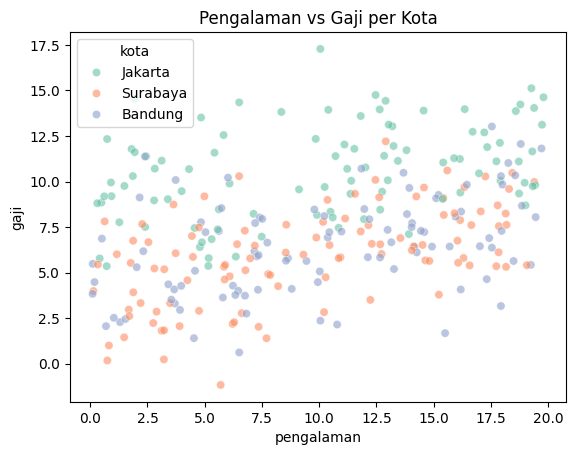

/tmp/ipykernel_3879/1558255470.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='kota', y='gaji', palette='Set2')


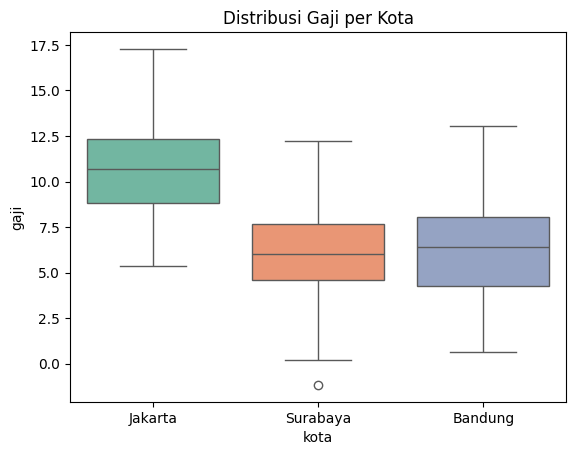

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)
kota       = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 0.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman,'edu':edu,'kota':kota,'gaji':gaji})
print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota'); plt.show()

sns.boxplot(data=df, x='kota', y='gaji', palette='Set2')
plt.title('Distribusi Gaji per Kota'); plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


β₀ (intercept): 7.772
        Fitur  Koefisien
 kota_Jakarta      1.837
          edu      1.188
   pengalaman      1.175
kota_Surabaya     -0.292


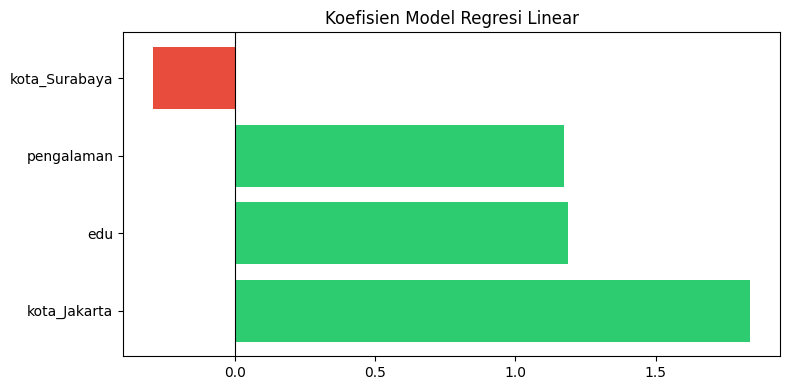

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')
coef_df = pd.DataFrame({
    'Fitur'    : X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in coef_df['Koefisien']]
plt.figure(figsize=(8,4))
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Koefisien Model Regresi Linear'); plt.tight_layout(); plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_s)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.6382  (63.8% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


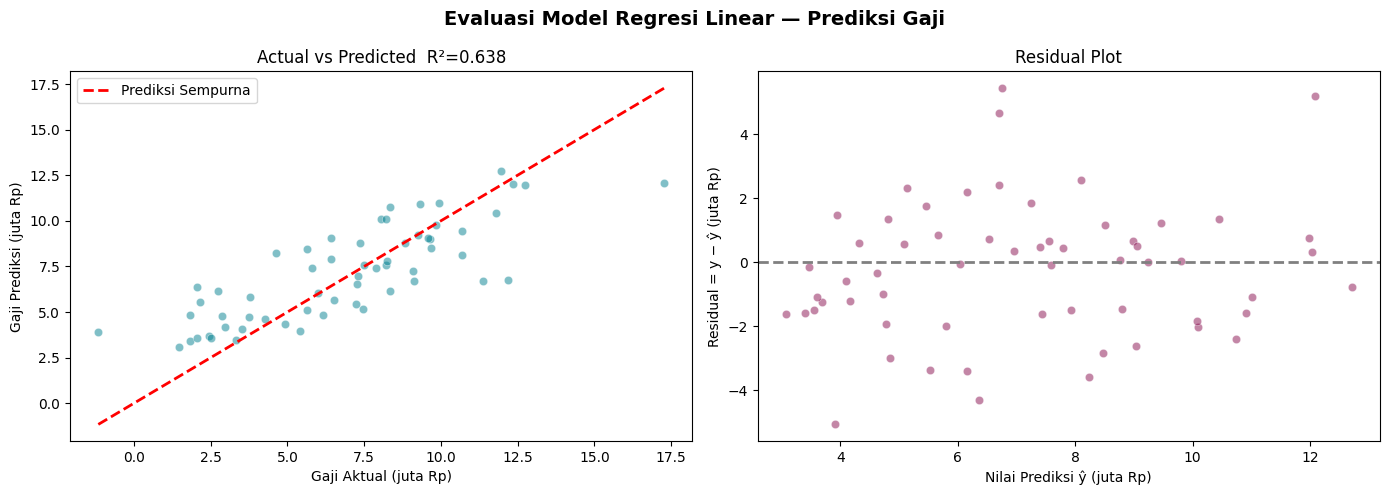

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)'); axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  R²={r2:.3f}'); axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)'); axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

## Kesimpulan — Pertemuan 7: Regresi Linear

Ini adalah pertemuan yang paling berkesan sejauh ini — pertama kalinya saya membangun model Machine Learning dari nol sampai menghasilkan prediksi nyata.

Yang paling menarik bagi saya adalah bagaimana koefisien model bisa langsung "bercerita". Sebelum praktikum ini, saya mengira model ML adalah kotak hitam yang sulit dipahami. Di Regresi Linear, ternyata setiap koefisien punya makna langsung: koefisien positif pada `kota_Jakarta` misalnya, secara eksplisit mengatakan bahwa bekerja di Jakarta memberi kontribusi nyata terhadap gaji — sesuai dengan kondisi di dunia nyata.

Evaluasi dengan tiga metrik sekaligus (MAE, RMSE, R²) juga memberi perspektif yang lebih lengkap. MAE mudah diinterpretasikan dalam satuan rupiah, perbandingan RMSE vs MAE memberi sinyal ada tidaknya prediksi yang sangat meleset, dan R² memberi gambaran keseluruhan seberapa baik model bekerja. Residual Plot juga membantu saya memvalidasi bahwa asumsi linearitas sudah terpenuhi.

Satu hal yang masih ingin saya eksplorasi: bagaimana performa model ini dibandingkan algoritma lain seperti Random Forest, terutama pada data nyata yang hubungannya tidak selalu linear.
